# Data Normalization

In [24]:
# import libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import PowerTransformer, QuantileTransformer


In [25]:
# make a ranodm non mormal data
data= np.random.exponential(scale=2, size=1000)
data= pd.DataFrame(data, columns=["values"])
data.head()

,values
0,0.179229
1,1.994147
2,2.126721
3,0.318367
4,0.154125


<Axes: xlabel='values', ylabel='Count'>

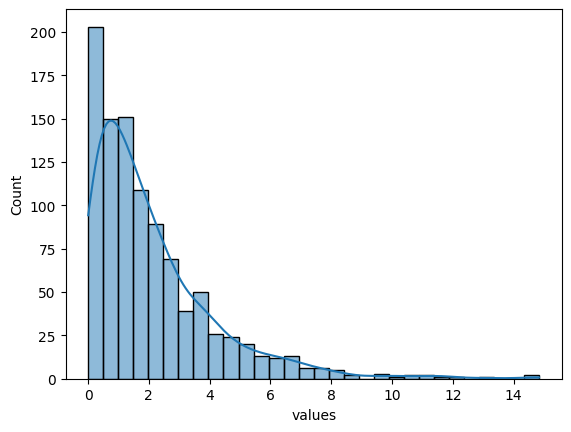

In [26]:
# make a histplot of this data
sns.histplot(data=data, x='values', bins=30, kde=True)

In [27]:
# Box-Cox and Yeo-Johnson transformations
pt_box_cox = PowerTransformer(method='box-cox', standardize=False)
pt_yeo_johnson = PowerTransformer(method='yeo-johnson', standardize=False)
qt_normal = QuantileTransformer(output_distribution='normal')

df = data.copy()

# boxcox ky lye +1 add krna lazmi hai
df['Box_Cox'] = pt_box_cox.fit_transform(df[['values']] + 1)
df['Yeo_Johnson'] = pt_yeo_johnson.fit_transform(df[['values']])
df['Quantile'] = qt_normal.fit_transform(df[['values']])

df.head(10)

,values,Box_Cox,Yeo_Johnson,Quantile
0,0.179229,0.160375,0.160375,-1.467860
1,1.994147,0.917203,0.917203,0.299230
2,2.126721,0.946951,0.946951,0.341493
3,0.318367,0.263941,0.263941,-1.149742
4,0.154125,0.139943,0.139943,-1.537691
5,4.644053,1.312081,1.312081,1.286702
6,0.831350,0.547481,0.547481,-0.478025
7,4.035986,1.247138,1.247138,1.102440
8,2.193710,0.961349,0.961349,0.389783
9,2.788542,1.073687,1.073687,0.664287


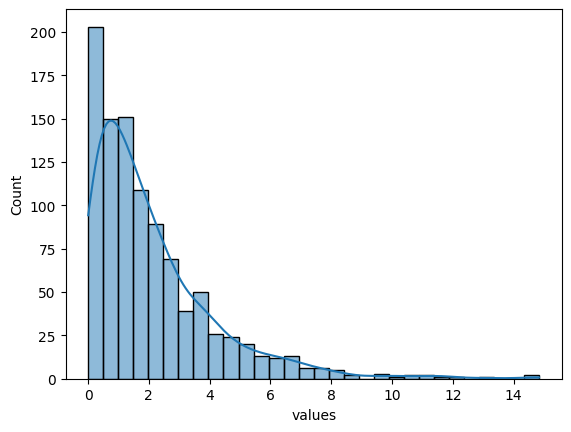

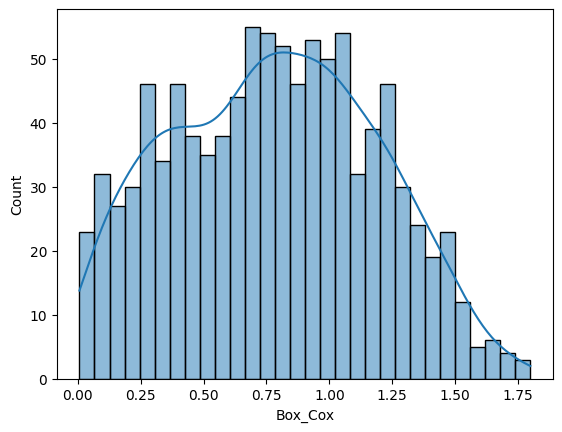

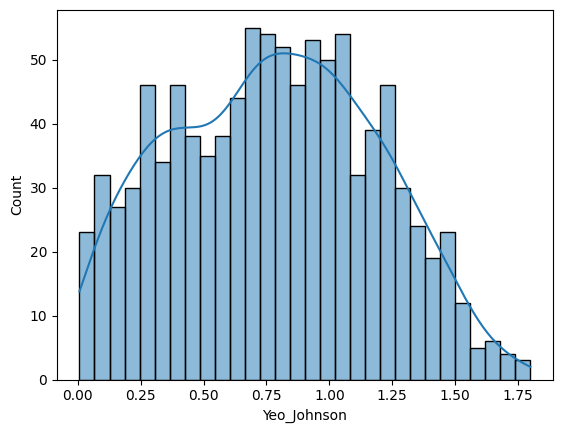

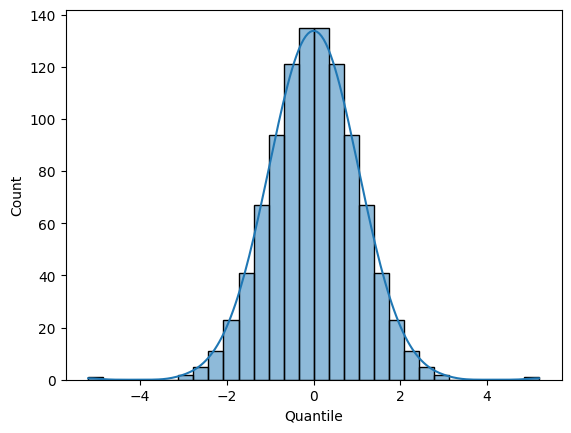

In [28]:
# now make a histogram of the transformed data
for col in ['values', 'Box_Cox', 'Yeo_Johnson', 'Quantile']:
    sns.histplot(data=df, bins=30, x=col, kde=True)
    plt.show()

# L1 and L2 Normalizer

In [29]:
# import libraries
from sklearn.preprocessing import Normalizer
data = [[1, 5, 1], [1, 0, 3], [0, 1, 4], [0, 1, 1]]

# normalize the data using L1 normalization
normalizer = Normalizer(norm='l1') 
normalized_data = normalizer.fit_transform(data)
normalized_data

array([[0.14285714, 0.71428571, 0.14285714],
       [0.25      , 0.        , 0.75      ],
       [0.        , 0.2       , 0.8       ],
       [0.        , 0.5       , 0.5       ]])

In [30]:
# data
data1 = [[4, 1, 2, 2], [1, 3, 9, 3], [5, 7, 5, 1]]

# normalize the data using L2 normalization
normalizer = Normalizer(norm='l2')
normalized_data1 = normalizer.fit_transform(data1)
normalized_data1

array([[0.8, 0.2, 0.4, 0.4],
       [0.1, 0.3, 0.9, 0.3],
       [0.5, 0.7, 0.5, 0.1]])

# Log Transformation

In [34]:
# make a dataset 
data = {
    'Values' : [1, 2, 3, 4, 5, 10, 50, 100, 500, 200, 400, 400, 500, 450, 230, 300, 400, 500, 600, 700, 800, 900, 1000, 1000, 50000, 100000, 200, 300, 4000, 5000]
}
data =pd.DataFrame(data)

# take a log of this data
data['log_values'] = np.log(data['Values'])
data.head(15)

,Values,log_values
0,1,0.000000
1,2,0.693147
2,3,1.098612
3,4,1.386294
4,5,1.609438
5,10,2.302585
6,50,3.912023
7,100,4.605170
8,500,6.214608
9,200,5.298317


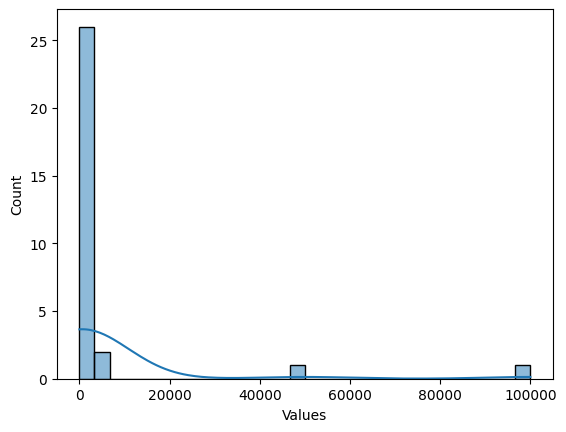

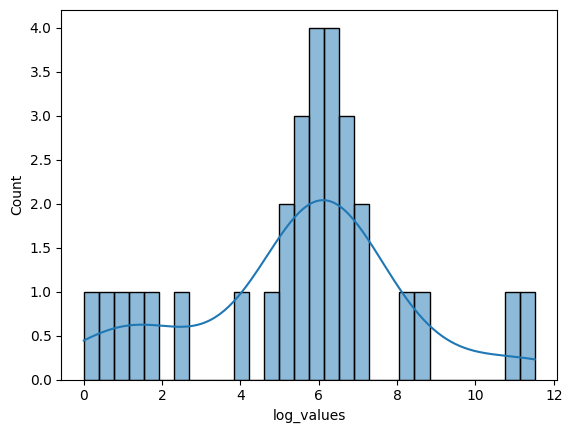

In [35]:
# draw a histogram of the original and log transformed data
for col in ['Values', 'log_values']:
    sns.histplot(data=data, kde=True, bins=30, x=col)
    plt.show()
